Please use this notebook to perform any initial analyses and model testing!

In [129]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [130]:
path = R'..\data\dataset.csv'
df = pd.read_csv(path)
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


In [131]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  str    
 1   cust_number             50000 non-null  str    
 2   name_customer           50000 non-null  str    
 3   clear_date              40000 non-null  str    
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  str    
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  str    
 11  document type           50000 non-null  str    
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null  float64
 

In [132]:
df = df.drop(columns=['area_business'])
df = df.dropna(subset=['invoice_id'])

In [133]:
df.info()

<class 'pandas.DataFrame'>
Index: 49994 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           49994 non-null  str    
 1   cust_number             49994 non-null  str    
 2   name_customer           49994 non-null  str    
 3   clear_date              39994 non-null  str    
 4   buisness_year           49994 non-null  float64
 5   doc_id                  49994 non-null  float64
 6   posting_date            49994 non-null  str    
 7   document_create_date    49994 non-null  int64  
 8   document_create_date.1  49994 non-null  int64  
 9   due_in_date             49994 non-null  float64
 10  invoice_currency        49994 non-null  str    
 11  document type           49994 non-null  str    
 12  posting_id              49994 non-null  float64
 13  total_open_amount       49994 non-null  float64
 14  baseline_create_date    49994 non-null  float64
 15  c

In [134]:
cat_var_cols = ['business_code', 'cust_number', 'doc_id', 'invoice_currency', 'document type', 'posting_id', 'cust_payment_terms', 'invoice_id', 'document_create_date', 'due_in_date']

for col in cat_var_cols:
    df[col] = df[col].astype(str)

df = df.rename(columns={'document type': 'doc_type', 'isOpen': 'is_open'})
df = df.drop(columns = ['document_create_date.1'])
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1930438491.0,2020-01-26,20200125,20200210.0,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1929646410.0,2019-07-22,20190722,20190811.0,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1929873765.0,2019-09-14,20190914,20190929.0,USD,RV,1.0,2253.86,20190914.0,NAA8,1929873765.0,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2960623488.0,2020-03-30,20200330,20200410.0,CAD,RV,1.0,3299.70,20200331.0,CA10,2960623488.0,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1930147974.0,2019-11-13,20191113,20191128.0,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0


In [135]:
df['posting_date'] = pd.to_datetime(df['posting_date']).dt.date
df['due_in_date'] = pd.to_datetime(df['due_in_date'], format='%Y%m%d.0').dt.date
df['document_create_date'] = pd.to_datetime(df['document_create_date'], format='%Y%m%d').dt.date
df['clear_date'] = pd.to_datetime(df['clear_date']).dt.date

df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020.0,1930438491.0,2020-01-26,2020-01-25,2020-02-10,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0
1,U001,0200980828,BEN E,2019-08-08,2019.0,1929646410.0,2019-07-22,2019-07-22,2019-08-11,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0
2,U001,0200792734,MDV/ trust,2019-12-30,2019.0,1929873765.0,2019-09-14,2019-09-14,2019-09-29,USD,RV,1.0,2253.86,20190914.0,NAA8,1929873765.0,0
3,CA02,0140105686,SYSC llc,NaT,2020.0,2960623488.0,2020-03-30,2020-03-30,2020-04-10,CAD,RV,1.0,3299.70,20200331.0,CA10,2960623488.0,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25,2019.0,1930147974.0,2019-11-13,2019-11-13,2019-11-28,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0


In [136]:
print(df['posting_date'].min())
print(df.loc[~df['clear_date'].isna()]['clear_date'].max())

2018-12-30
2020-05-22


<StringArray>
['NAH4', 'NAD1', 'NAA8', 'CA10', 'NAC6', 'NAM2', 'NAAX', 'NAVE', 'NAG2',
 'NABG', 'NAM4', 'NA10', 'NAU5', 'NA32', 'NAD5', 'NAWP', 'NAGD', 'NAVR',
 'CA30', 'NAM1', 'NAAW', 'NAVF', 'NAD4', 'NAUZ', 'NA3F', 'NAX2', 'NAVQ',
 'NATM', 'CAB1', 'NA84', 'NAWM', 'NACB', 'NACG', 'NA38', 'NAWN', 'C106',
 'NAWU', 'NAB1', 'NA3B', 'NA9X', 'NAVD', 'NAVM', 'NACE', 'NA25', 'NAUP',
 'NAM3', 'NACH', 'CAX2', 'NATV', 'NAVL', 'NATZ', 'C129', 'BR56', 'NA31',
 'NATW', 'B052', 'NAV2', 'NATX', 'NAUY', 'NA8Q', 'NATJ', 'BR12', 'NATU',
 '90M7', 'NAV9', 'NATK', 'CA60', 'NATL', 'NAD8', 'NAUW', 'NAVC', 'NABD',
 'NATH', 'MC15']
Length: 74, dtype: str


C:\Users\Corey\AppData\Local\Temp\ipykernel_20776\1901737068.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )


[Text(0, 0, 'NAH4'),
 Text(1, 0, 'NAD1'),
 Text(2, 0, 'NAA8'),
 Text(3, 0, 'CA10'),
 Text(4, 0, 'NAC6'),
 Text(5, 0, 'NAM2'),
 Text(6, 0, 'NAAX'),
 Text(7, 0, 'NAVE'),
 Text(8, 0, 'NAG2'),
 Text(9, 0, 'NABG'),
 Text(10, 0, 'NAM4'),
 Text(11, 0, 'NA10'),
 Text(12, 0, 'NAU5'),
 Text(13, 0, 'NA32'),
 Text(14, 0, 'NAD5'),
 Text(15, 0, 'NAWP'),
 Text(16, 0, 'NAGD'),
 Text(17, 0, 'NAVR'),
 Text(18, 0, 'CA30'),
 Text(19, 0, 'NAM1'),
 Text(20, 0, 'NAAW'),
 Text(21, 0, 'NAVF'),
 Text(22, 0, 'NAD4'),
 Text(23, 0, 'NAUZ'),
 Text(24, 0, 'NA3F'),
 Text(25, 0, 'NAX2'),
 Text(26, 0, 'NAVQ'),
 Text(27, 0, 'NATM'),
 Text(28, 0, 'CAB1'),
 Text(29, 0, 'NA84'),
 Text(30, 0, 'NAWM'),
 Text(31, 0, 'NACB'),
 Text(32, 0, 'NA38'),
 Text(33, 0, 'NAWN'),
 Text(34, 0, 'C106'),
 Text(35, 0, 'NAWU'),
 Text(36, 0, 'NAB1'),
 Text(37, 0, 'NA3B'),
 Text(38, 0, 'NA9X'),
 Text(39, 0, 'NAVD'),
 Text(40, 0, 'NAVM'),
 Text(41, 0, 'NACE'),
 Text(42, 0, 'NA25'),
 Text(43, 0, 'NAUP'),
 Text(44, 0, 'NACH'),
 Text(45, 0, 'CAX2')

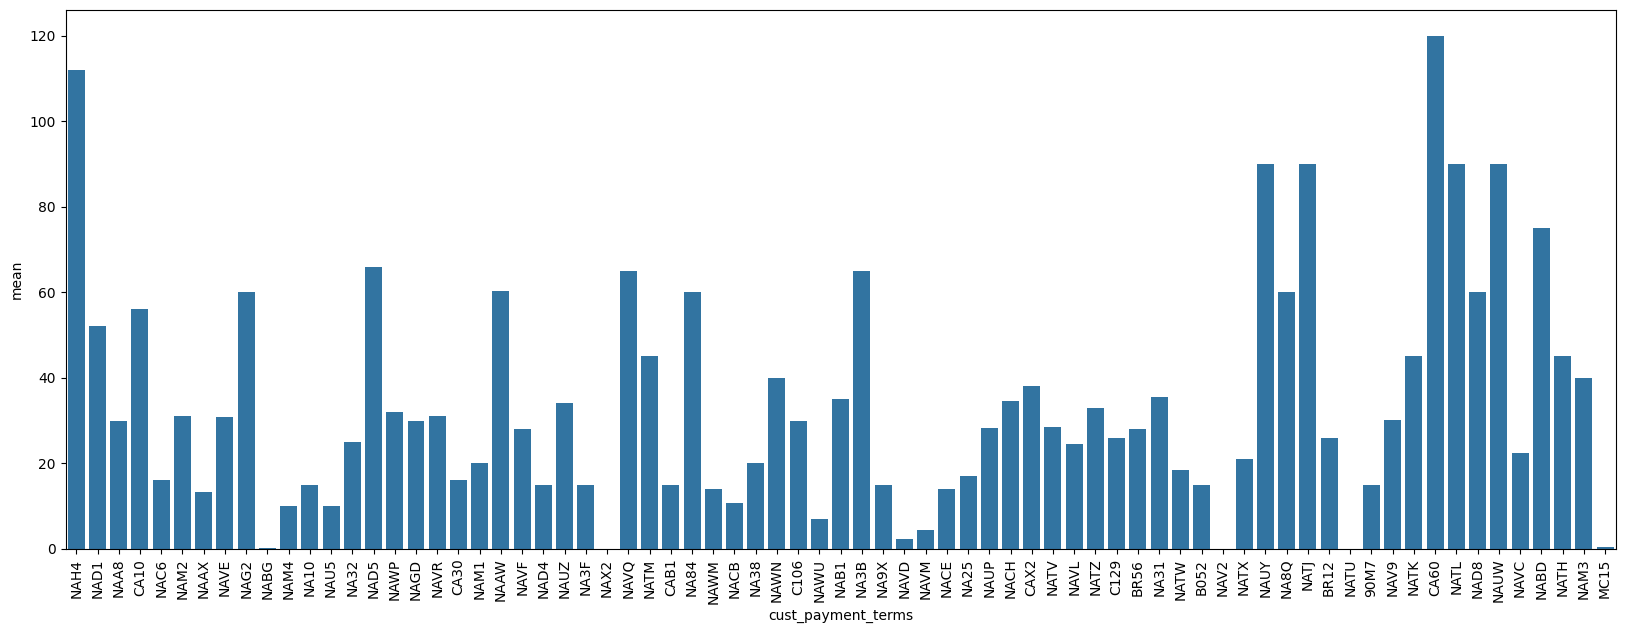

In [137]:
print(df['cust_payment_terms'].unique())
df['due_terms_on_invoice'] = pd.to_timedelta(df['due_in_date'] - df['posting_date']).dt.days

df = df.loc[df['due_terms_on_invoice'] >= 0]

terms_grouped = df.groupby('cust_payment_terms')['due_terms_on_invoice'].agg(['mean', 'min', 'max', 'count']).reset_index()

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.barplot(data = terms_grouped, x = 'cust_payment_terms', y = 'mean', ax = ax)
ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )

C:\Users\Corey\AppData\Local\Temp\ipykernel_20776\3975752270.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )


[Text(0, 0, 'NAH4'),
 Text(1, 0, 'NAD1'),
 Text(2, 0, 'NAA8'),
 Text(3, 0, 'CA10'),
 Text(4, 0, 'NAC6'),
 Text(5, 0, 'NAM2'),
 Text(6, 0, 'NAAX'),
 Text(7, 0, 'NAVE'),
 Text(8, 0, 'NAG2'),
 Text(9, 0, 'NABG'),
 Text(10, 0, 'NAM4'),
 Text(11, 0, 'NA10'),
 Text(12, 0, 'NAU5'),
 Text(13, 0, 'NA32'),
 Text(14, 0, 'NAD5'),
 Text(15, 0, 'NAWP'),
 Text(16, 0, 'NAGD'),
 Text(17, 0, 'NAVR'),
 Text(18, 0, 'CA30'),
 Text(19, 0, 'NAM1'),
 Text(20, 0, 'NAAW'),
 Text(21, 0, 'NAVF'),
 Text(22, 0, 'NAD4'),
 Text(23, 0, 'NAUZ'),
 Text(24, 0, 'NA3F'),
 Text(25, 0, 'NAX2'),
 Text(26, 0, 'NAVQ'),
 Text(27, 0, 'NATM'),
 Text(28, 0, 'CAB1'),
 Text(29, 0, 'NA84'),
 Text(30, 0, 'NAWM'),
 Text(31, 0, 'NACB'),
 Text(32, 0, 'NA38'),
 Text(33, 0, 'NAWN'),
 Text(34, 0, 'C106'),
 Text(35, 0, 'NAWU'),
 Text(36, 0, 'NAB1'),
 Text(37, 0, 'NA3B'),
 Text(38, 0, 'NA9X'),
 Text(39, 0, 'NAVD'),
 Text(40, 0, 'NAVM'),
 Text(41, 0, 'NACE'),
 Text(42, 0, 'NA25'),
 Text(43, 0, 'NAUP'),
 Text(44, 0, 'NACH'),
 Text(45, 0, 'CAX2')

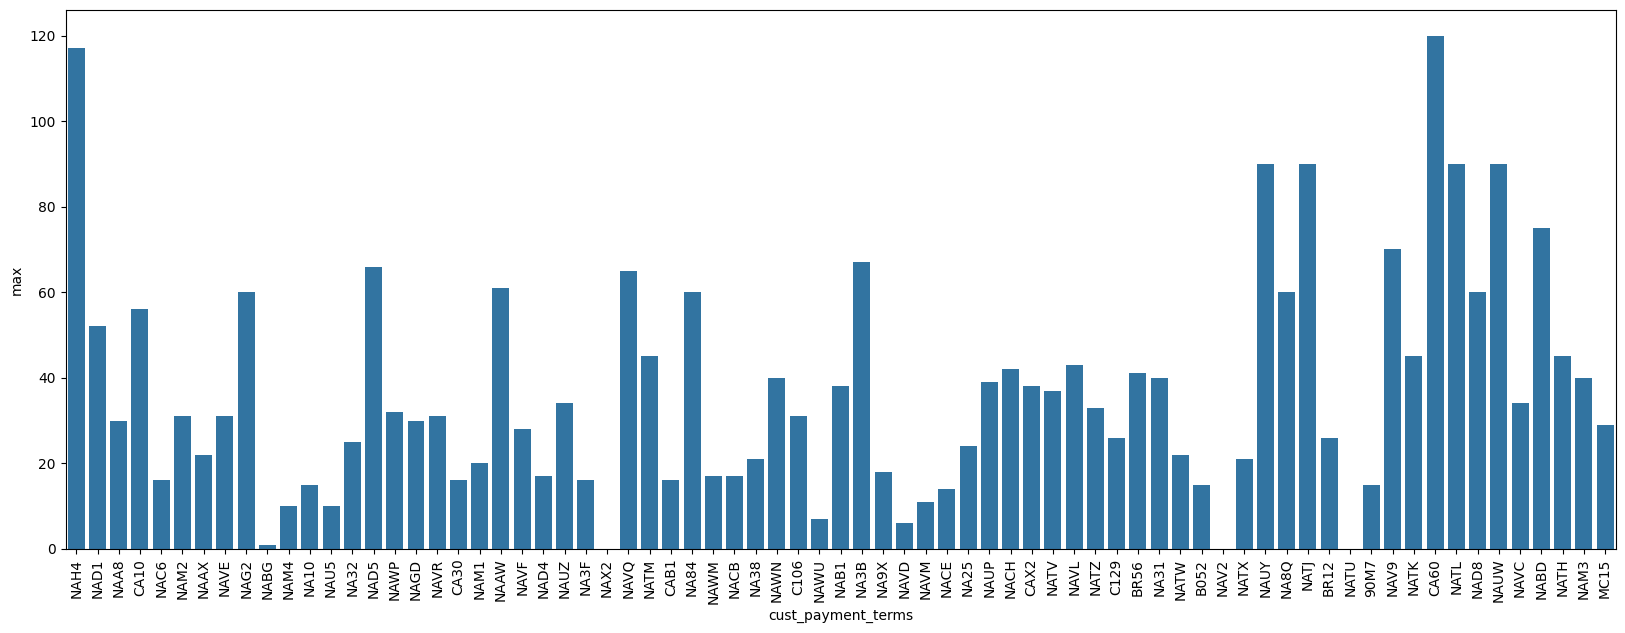

In [138]:
fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.barplot(data = terms_grouped, x = 'cust_payment_terms', y = 'max', ax = ax)
ax.set_xticklabels(rotation = 90, labels= df['cust_payment_terms'].unique() )

In [139]:
df_paid = df.loc[~df['clear_date'].isna()]
df_paid['paid_date_diff'] = pd.to_timedelta(df_paid['clear_date'] - df_paid['due_in_date']).dt.days
df_paid_grouped = df_paid.groupby('cust_payment_terms')['paid_date_diff'].agg(['mean', 'min', 'max', 'count']).reset_index()

df_paid_grouped

,cust_payment_terms,mean,min,max,count
0,90M7,-41.800000,-87,-1,5
1,B052,-9.000000,-40,11,3
2,BR12,-2.500000,-5,0,2
3,BR56,4.600000,-1,14,10
4,C106,-0.666667,-4,2,12
...,...,...,...,...,...
65,NAWM,4.000000,4,4,4
66,NAWN,-3.123711,-69,90,97
67,NAWP,-8.238806,-9,-4,67
68,NAWU,-6.282051,-31,6,117


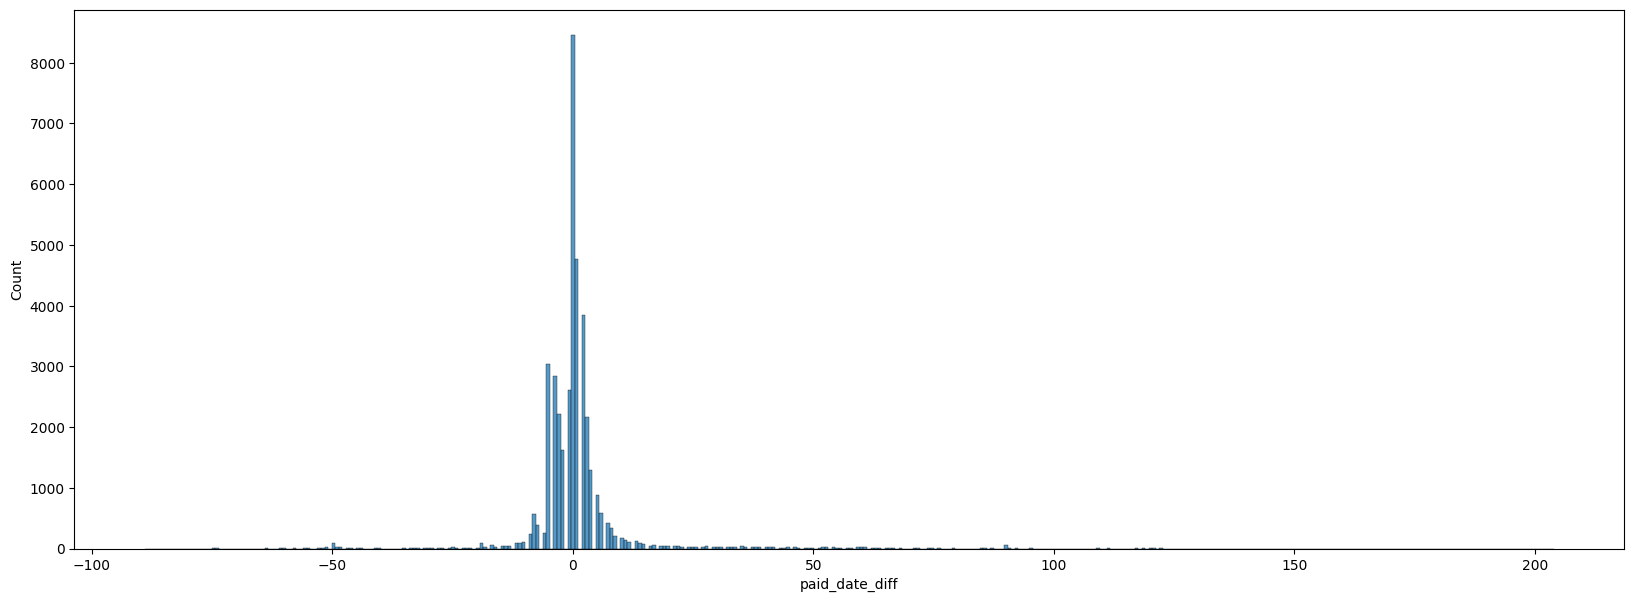

In [140]:
fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid, x = 'paid_date_diff')

-3.0
2.0
5.0
-10.5
9.5


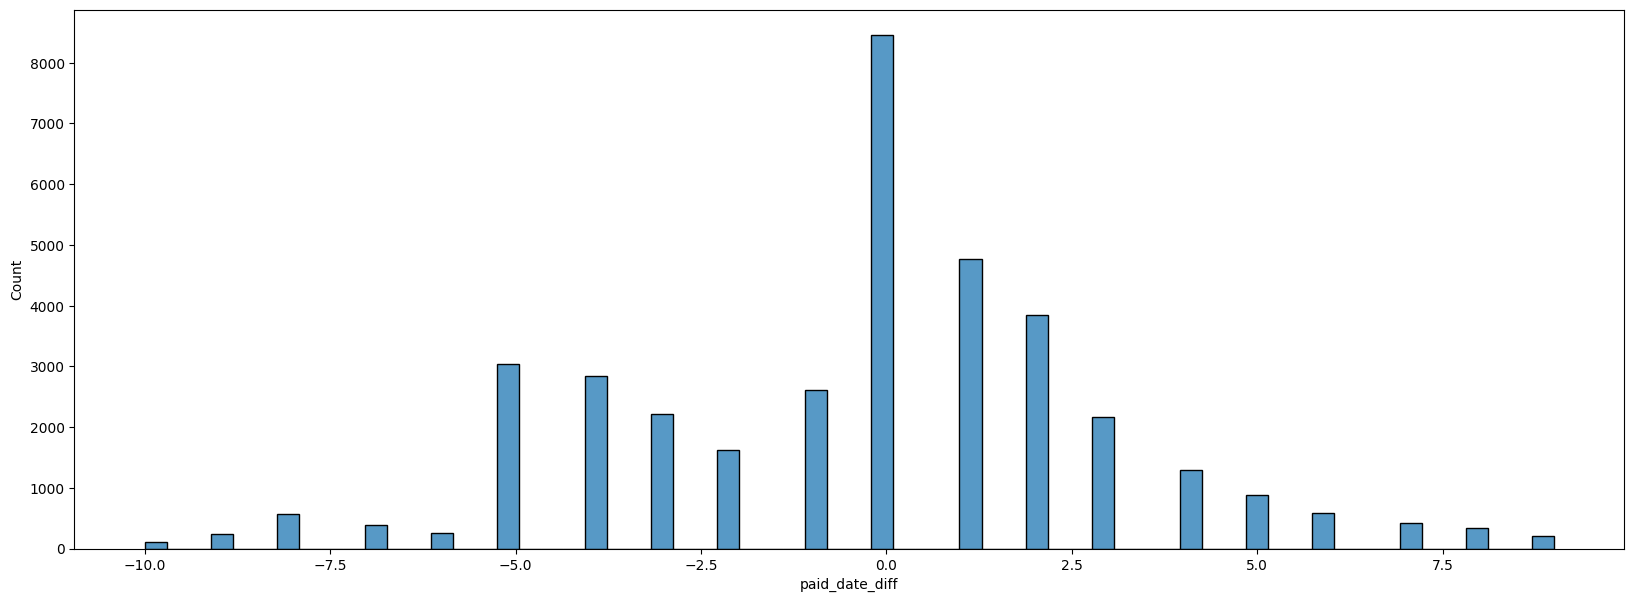

In [141]:
targ_var_lq = np.percentile(df_paid['paid_date_diff'], 25)
targ_var_uq = np.percentile(df_paid['paid_date_diff'], 75)
targ_var_iqr = targ_var_uq - targ_var_lq
targ_var_lt = targ_var_lq - (1.5 * targ_var_iqr)
targ_var_ut = targ_var_uq + (1.5 * targ_var_iqr)

print(targ_var_lq)
print(targ_var_uq)
print(targ_var_iqr)
print(targ_var_lt)
print(targ_var_ut)

df_paid_clean = df_paid.loc[df_paid['paid_date_diff'].between(targ_var_lt, targ_var_ut)]

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid_clean, x = 'paid_date_diff')

In [142]:
targ_var_std = np.std(df_paid['paid_date_diff'])
targ_var_mean = np.mean(df_paid['paid_date_diff'])

mean_plus_one_std = targ_var_mean + (targ_var_std)
mean_plus_two_std = targ_var_mean + (targ_var_std * 2)
mean_plus_three_std = targ_var_mean + (targ_var_std * 3)

mean_minus_one_std = targ_var_mean - (targ_var_std)
mean_minus_two_std = targ_var_mean - (targ_var_std * 2)
mean_minus_three_std = targ_var_mean - (targ_var_std * 3)

print(mean_minus_three_std)
print(mean_minus_two_std)
print(mean_minus_one_std)
print(targ_var_mean)
print(mean_plus_one_std)
print(mean_plus_two_std)
print(mean_plus_three_std)

-31.58253030901999
-20.783392983122564
-9.984255657225141
0.8148816686722824
11.614018994569705
22.413156320467127
33.21229364636456


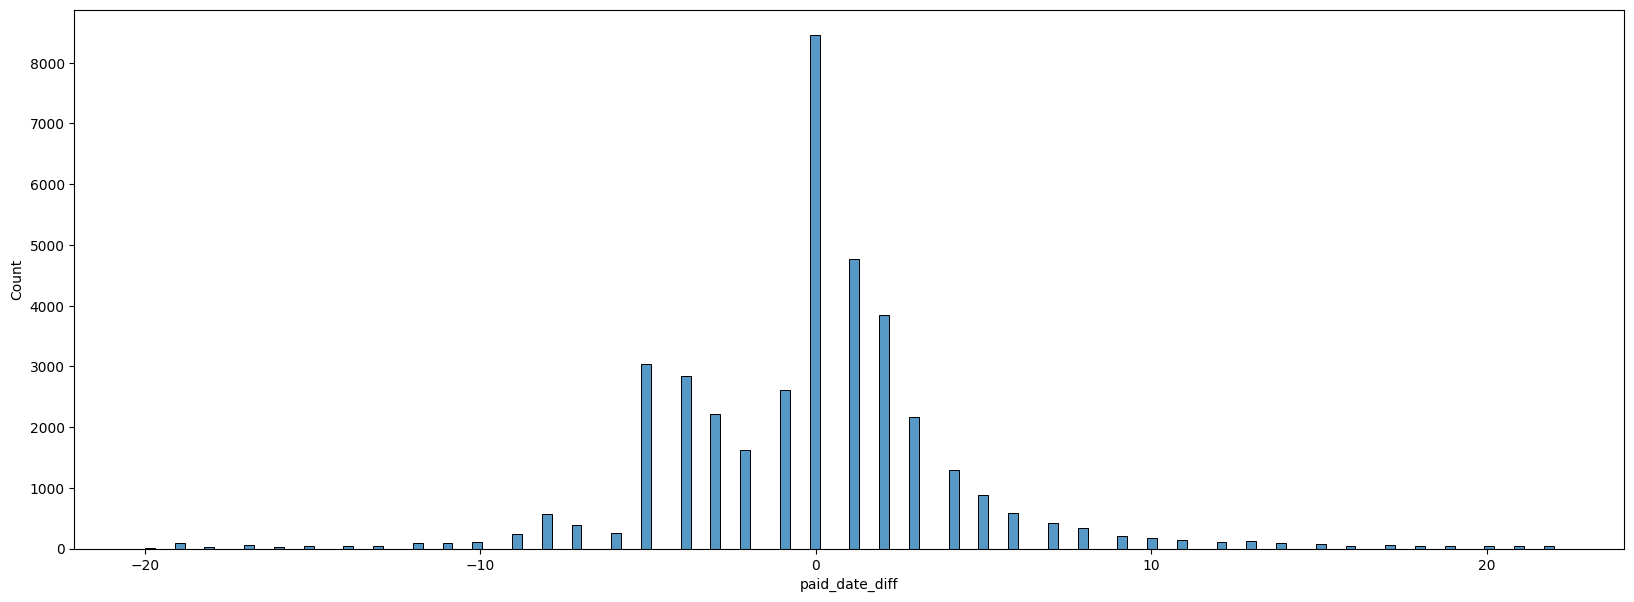

In [143]:
df_paid_clean = df_paid.loc[df_paid['paid_date_diff'].between(mean_minus_two_std, mean_plus_two_std)]

fig, ax = plt.subplots(figsize = [20, 7])
_ = sns.histplot(data = df_paid_clean, x = 'paid_date_diff')

In [144]:
df_paid_clean.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open,due_terms_on_invoice,paid_date_diff
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020.0,1930438491.0,2020-01-26,2020-01-25,2020-02-10,USD,RV,1.0,54273.28,20200126.0,NAH4,1930438491.0,0,15,1
1,U001,0200980828,BEN E,2019-08-08,2019.0,1929646410.0,2019-07-22,2019-07-22,2019-08-11,USD,RV,1.0,79656.60,20190722.0,NAD1,1929646410.0,0,20,-3
4,U001,0200769623,WAL-MAR foundation,2019-11-25,2019.0,1930147974.0,2019-11-13,2019-11-13,2019-11-28,USD,RV,1.0,33133.29,20191113.0,NAH4,1930147974.0,0,15,-3
6,U001,0200769623,WAL-MAR in,2019-11-12,2019.0,1930083373.0,2019-11-01,2019-10-31,2019-11-16,USD,RV,1.0,7358.49,20191101.0,NAH4,1930083373.0,0,15,-4
8,U001,0200769623,WAL-MAR corp,2019-06-18,2019.0,1929439637.0,2019-06-07,2019-06-05,2019-06-22,USD,RV,1.0,15995.04,20190607.0,NAH4,1929439637.0,0,15,-4


In [145]:
df_paid_clean = df_paid_clean.sort_values(['cust_number', 'document_create_date'])
df_paid_clean['invoice_count'] = df_paid_clean.groupby('cust_number')['invoice_id'].transform(lambda x: x.count())

df_paid_clean

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,due_in_date,invoice_currency,doc_type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,is_open,due_terms_on_invoice,paid_date_diff,invoice_count
10487,U001,0100000051,GREE systems,2019-10-10,2019.0,1929850450.0,2019-09-09,2019-09-09,2019-10-09,USD,RV,1.0,37169.00,20190909.0,NAD5,1929850450.0,0,30,1,1
22254,U001,0100000158,CASC trust,2019-09-27,2019.0,1929465352.0,2019-06-12,2019-06-10,2019-09-10,USD,RV,1.0,57170.04,20190612.0,NAVM,1929465352.0,0,90,17,3
38143,U001,0100000158,CASC trust,2019-09-27,2019.0,1929465352.0,2019-06-12,2019-06-10,2019-09-10,USD,RV,1.0,57170.04,20190612.0,NAVM,1929465352.0,0,90,17,3
31866,U001,0100000158,CASC foundation,2019-09-27,2019.0,1929508202.0,2019-06-17,2019-06-17,2019-09-15,USD,RV,1.0,27179.53,20190617.0,NAVM,1929508202.0,0,90,12,3
6985,U001,0100000217,MRS S associates,2019-03-05,2019.0,1928792791.0,2019-02-19,2019-02-13,2019-03-06,USD,RV,1.0,34908.78,20190219.0,NAA8,1928792791.0,0,15,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26202,U001,CCU002,KRFT FDS llc,2020-03-27,2020.0,1930554129.0,2020-02-25,2020-02-21,2020-03-31,USD,RV,1.0,16430.89,20200225.0,NAG2,1930554129.0,0,35,-4,113
26467,CA02,CCU013,KRAFT F corp,2019-05-31,2019.0,2960542066.0,2019-04-16,2019-04-16,2019-05-15,CAD,RV,1.0,19367.70,20190515.0,NAX2,2960542066.0,0,29,16,4
42509,CA02,CCU013,KRAFT F corp,2019-05-31,2019.0,2960542066.0,2019-04-16,2019-04-16,2019-05-15,CAD,RV,1.0,19367.70,20190515.0,NAX2,2960542066.0,0,29,16,4
7205,U001,CCU013,KRAFT F us,2019-12-20,2019.0,1930185327.0,2019-11-28,2019-11-22,2019-11-28,USD,RV,1.0,3846.48,20191128.0,NAX2,1930185327.0,0,0,22,4
